Generating spiral with θ = √n (structured)...
SPIRAL PATTERN ANALYSIS
Theta function: <lambda>
N = 30000, Primes = 3245

[1] AUTOCORRELATION ANALYSIS
  Radial autocorrelation strength:   83.8091
  Angular autocorrelation strength:  3.5431

[2] FRACTAL DIMENSION ANALYSIS


/tmp/ipykernel_9103/4154567630.py:154: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  strength = np.trapz(np.abs(autocorr_normalized), dx=1)


  Box-counting dimension:  0.1888
  Correlation dimension:   1.7552

[3] ENTROPY ANALYSIS
  Radial entropy:          6.4498 bits
  Angular entropy:         3.5850 bits
  Joint entropy:           3.5850 bits
  Normalized radial:       0.5530
  Normalized angular:      0.3074
  Mutual information:      6.4498 bits

OVERALL STRUCTURE SCORE: 88.6807
(Higher = more structured, Lower = more random)


Generating spiral with θ = n² (unstructured)...
SPIRAL PATTERN ANALYSIS
Theta function: <lambda>
N = 30000, Primes = 3245

[1] AUTOCORRELATION ANALYSIS
  Radial autocorrelation strength:   83.8091
  Angular autocorrelation strength:  0.7159

[2] FRACTAL DIMENSION ANALYSIS
  Box-counting dimension:  0.1888
  Correlation dimension:   1.7143

[3] ENTROPY ANALYSIS
  Radial entropy:          6.4498 bits
  Angular entropy:         -0.0000 bits
  Joint entropy:           -0.0000 bits
  Normalized radial:       0.5530
  Normalized angular:      -0.0000
  Mutual information:      6.4498 bits

OVERALL STR

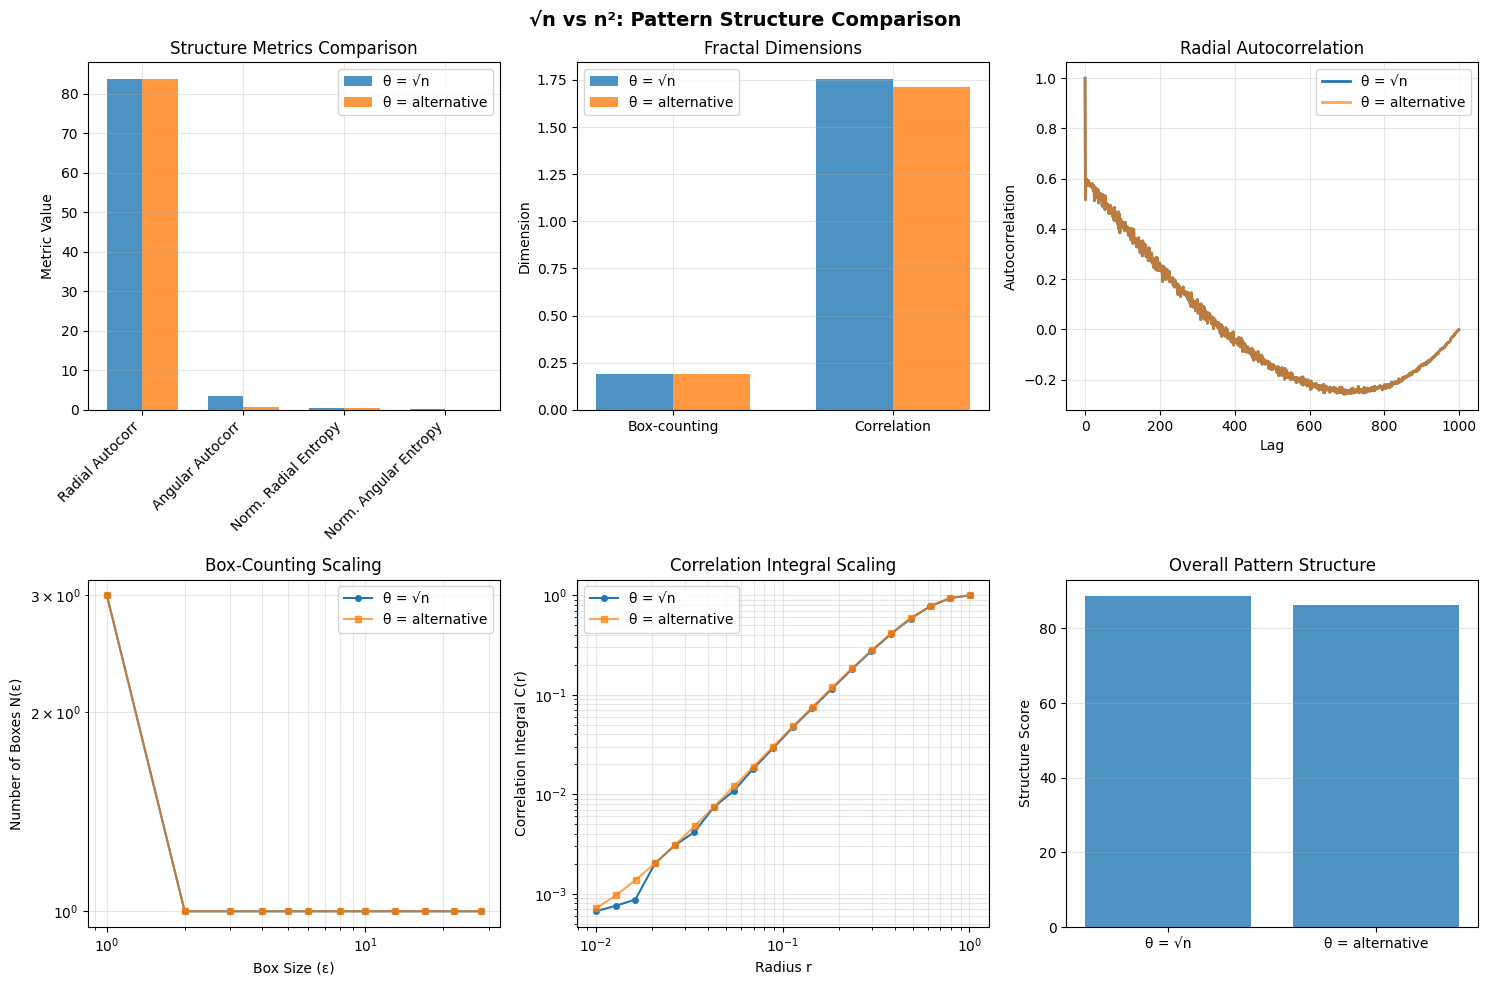

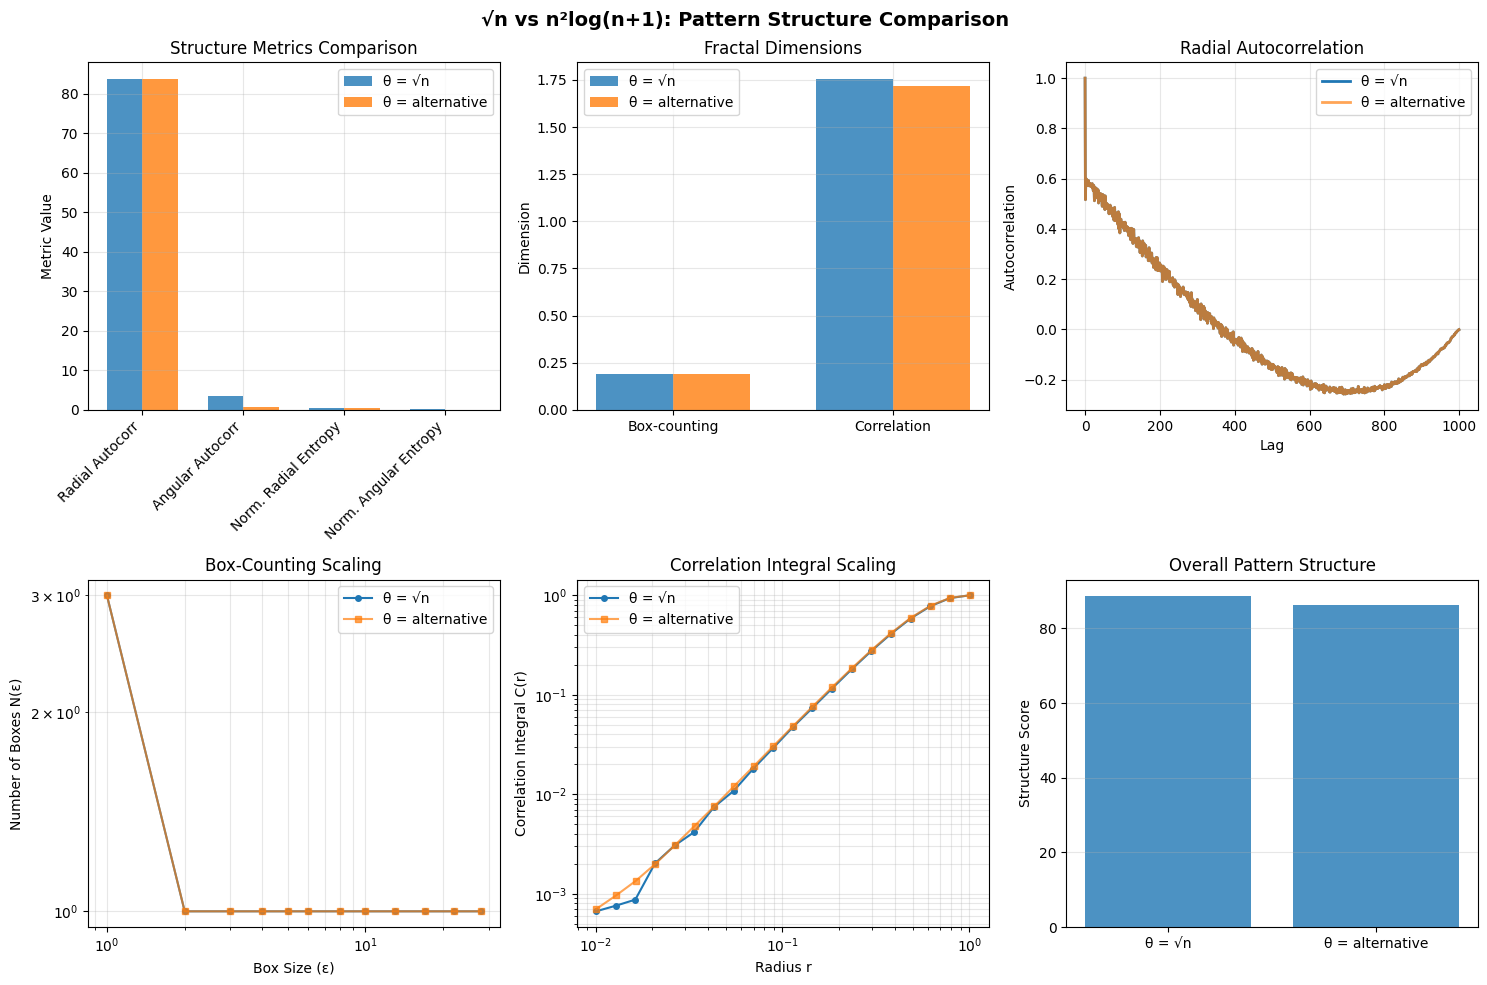

In [ ]:
"""
spiral_pattern_analysis.py
==========================
Quantitative metrics for analyzing pattern structure in number spirals.
Implements: Autocorrelation, Fractal Dimension, and Entropy measures.

Author: [Your Name]
For: "The Arithmetic Singularity: Why Prime Patterns Suggest Finite Recursion"
"""

import numpy as np
from scipy import signal, fft
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict
import warnings

class SpiralPatternAnalyzer:
    """
    Quantitative analysis of pattern structure in polar number spirals.

    Metrics:
    1. Autocorrelation of prime positions
    2. Fractal dimension (box-counting and correlation dimension)
    3. Entropy of radial and angular distributions
    """

    def __init__(self, n_max: int = 30000, theta_function=None):
        """
        Initialize spiral analyzer.

        Parameters:
        -----------
        n_max : int
            Maximum integer to include in spiral
        theta_function : callable
            Function mapping n -> theta (angle in radians)
            Default: theta = sqrt(n)
        """
        self.n_max = n_max
        self.theta_func = theta_function if theta_function else lambda n: np.sqrt(n)

        # Generate spiral coordinates
        self.numbers = np.arange(1, n_max + 1)
        self.radii = np.sqrt(self.numbers)  # Standard Ulam spiral radius
        self.angles = self.theta_func(self.numbers)

        # Convert to Cartesian
        self.x = self.radii * np.cos(self.angles)
        self.y = self.radii * np.sin(self.angles)

        # Identify primes
        self.is_prime = self._sieve_of_eratosthenes(n_max)
        self.is_prime = self.is_prime[1:]  # FIX: Skip index 0 to match numbers array (1 to n_max)
        self.primes = self.numbers[self.is_prime]

        # Prime positions
        self.prime_x = self.x[self.is_prime]
        self.prime_y = self.y[self.is_prime]

    def _sieve_of_eratosthenes(self, n: int) -> np.ndarray:
        """Generate prime sieve up to n."""
        sieve = np.ones(n + 1, dtype=bool)
        sieve[0:2] = False
        for i in range(2, int(n**0.5) + 1):
            if sieve[i]:
                sieve[i*i:n+1:i] = False
        return sieve

    # =========================================================================
    # 1. AUTOCORRELATION ANALYSIS
    # =========================================================================

    def compute_radial_autocorrelation(self,
                                       n_bins: int = 1000,
                                       normalize: bool = True) -> Tuple[np.ndarray, np.ndarray]:
        """
        Compute autocorrelation of prime density along radial dimension.
        """
        # Bin primes by radius
        max_radius = np.max(self.radii)
        bin_edges = np.linspace(0, max_radius, n_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Count primes per radial bin
        prime_radial_hist, _ = np.histogram(self.radii[self.is_prime], bins=bin_edges)

        # Compute autocorrelation using FFT (Wiener-Khinchin theorem)
        if normalize:
            signal_data = prime_radial_hist - np.mean(prime_radial_hist)
            signal_data = signal_data / np.std(prime_radial_hist)
        else:
            signal_data = prime_radial_hist

        # FFT-based autocorrelation
        fft_signal = fft.fft(signal_data, n=2*len(signal_data))
        autocorr_full = fft.ifft(fft_signal * np.conj(fft_signal)).real

        # Take only positive lags
        autocorr = autocorr_full[:len(signal_data)]

        # Normalize by variance
        if normalize:
            autocorr = autocorr / len(signal_data)

        lags = np.arange(len(autocorr))

        return lags, autocorr

    def compute_angular_autocorrelation(self,
                                        n_bins: int = 360,
                                        normalize: bool = True) -> Tuple[np.ndarray, np.ndarray]:
        """
        Compute autocorrelation of prime density in angular dimension.
        """
        # Bin primes by angle
        bin_edges = np.linspace(0, 2*np.pi, n_bins + 1)

        # Count primes per angular bin
        prime_angular_hist, _ = np.histogram(self.angles[self.is_prime], bins=bin_edges)

        if normalize:
            signal_data = prime_angular_hist - np.mean(prime_angular_hist)
            signal_data = signal_data / np.std(prime_angular_hist)
        else:
            signal_data = prime_angular_hist

        # FFT-based autocorrelation
        fft_signal = fft.fft(signal_data, n=2*len(signal_data))
        autocorr_full = fft.ifft(fft_signal * np.conj(fft_signal)).real

        autocorr = autocorr_full[:len(signal_data)]

        if normalize:
            autocorr = autocorr / len(signal_data)

        lags = np.arange(len(autocorr))

        return lags, autocorr

    def autocorrelation_strength(self, lags: np.ndarray,
                                 autocorr: np.ndarray,
                                 max_lag_fraction: float = 0.2) -> float:
        """
        Quantify the strength of autocorrelation structure.
        """
        max_lag = int(len(lags) * max_lag_fraction)

        # Measure decay rate of autocorrelation
        autocorr_normalized = autocorr[:max_lag] / autocorr[0]

        # Area under autocorrelation curve (up to max_lag)
        strength = np.trapz(np.abs(autocorr_normalized), dx=1)

        return strength

    # =========================================================================
    # 2. FRACTAL DIMENSION ANALYSIS
    # =========================================================================

    def box_counting_dimension(self,
                               scales: List[int] = None,
                               n_scales: int = 15) -> Tuple[np.ndarray, np.ndarray, float]:
        """
        Calculate box-counting (Minkowski-Bouligand) dimension.
        """
        # Combine x, y coordinates
        points = np.column_stack([self.prime_x, self.prime_y])

        # Normalize to [0, 1] - FIX: Use np.ptp instead of points.ptp (NumPy 2.0)
        points_norm = (points - points.min(axis=0)) / (np.ptp(points, axis=0))

        # Generate scales if not provided
        if scales is None:
            max_scale = int(np.sqrt(len(points)) / 2)
            scales = np.logspace(0, np.log10(max_scale), n_scales).astype(int)
            scales = np.unique(scales)  # Remove duplicates

        counts = []

        for box_size in scales:
            if box_size <= 0:
                counts.append(len(points))
                continue

            # Discretize points into boxes
            discrete = np.floor(points_norm * (1.0 / box_size)).astype(int)

            # Count unique boxes (non-empty)
            unique_boxes = np.unique(discrete, axis=0)
            counts.append(len(unique_boxes))

        counts = np.array(counts)

        # Calculate dimension from slope of log-log plot
        valid = (counts > 0) & (np.array(scales) > 0)
        if np.sum(valid) < 3:
            warnings.warn("Insufficient valid scales for dimension estimation")
            return np.array(scales), counts, np.nan

        log_sizes = np.log(1.0 / np.array(scales)[valid])
        log_counts = np.log(counts[valid])

        # Linear regression
        slope, intercept = np.polyfit(log_sizes, log_counts, 1)
        dimension = slope

        return np.array(scales), counts, dimension

    def correlation_dimension(self,
                              n_points: int = 5000,
                              radii: np.ndarray = None,
                              n_radii: int = 20) -> Tuple[np.ndarray, np.ndarray, float]:
        """
        Calculate correlation dimension (Grassberger-Procaccia algorithm).
        """
        # Sample points for speed
        if len(self.prime_x) > n_points:
            indices = np.random.choice(len(self.prime_x), n_points, replace=False)
            x_sample = self.prime_x[indices]
            y_sample = self.prime_y[indices]
        else:
            x_sample = self.prime_x
            y_sample = self.prime_y

        points = np.column_stack([x_sample, y_sample])

        # Normalize
        points_norm = (points - points.mean(axis=0)) / np.ptp(points, axis=0)

        # Compute pairwise distances
        distances = squareform(pdist(points_norm, metric='euclidean'))

        # Generate radii if not provided
        if radii is None:
            max_r = np.max(distances)
            min_r = max_r / 100
            radii = np.logspace(np.log10(min_r), np.log10(max_r), n_radii)

        # Calculate correlation integral C(r)
        c_values = []

        for r in radii:
            # Count pairs with distance < r
            n_pairs = np.sum(distances < r)
            c_values.append(n_pairs / (len(points) ** 2))

        c_values = np.array(c_values)

        # Dimension from slope of log-log plot
        valid = (c_values > 0) & (radii > 0)
        if np.sum(valid) < 3:
            return radii, c_values, np.nan

        log_r = np.log(radii[valid])
        log_c = np.log(c_values[valid])

        slope, intercept = np.polyfit(log_r, log_c, 1)
        dimension = slope

        return radii, c_values, dimension

    # =========================================================================
    # 3. ENTROPY ANALYSIS
    # =========================================================================

    def radial_entropy(self,
                       n_bins: int = 100,
                       base: float = 2) -> Tuple[float, np.ndarray, np.ndarray]:
        """
        Calculate Shannon entropy of radial distribution.
        """
        max_radius = np.max(self.radii)
        bin_edges = np.linspace(0, max_radius, n_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Histogram of prime radii
        counts, _ = np.histogram(self.radii[self.is_prime], bins=bin_edges)

        # Convert to probability
        probabilities = counts / counts.sum()

        # Remove zero probabilities
        probabilities = probabilities[probabilities > 0]

        # Shannon entropy
        entropy = -np.sum(probabilities * np.log(probabilities) / np.log(base))

        return entropy, bin_centers, counts / counts.sum()

    def angular_entropy(self,
                        n_bins: int = 360,
                        base: float = 2) -> Tuple[float, np.ndarray, np.ndarray]:
        """
        Calculate Shannon entropy of angular distribution.
        """
        bin_edges = np.linspace(0, 2*np.pi, n_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Histogram of prime angles
        counts, _ = np.histogram(self.angles[self.is_prime], bins=bin_edges)

        # Convert to probability
        probabilities = counts / counts.sum()

        # Remove zero probabilities
        probabilities = probabilities[probabilities > 0]

        # Shannon entropy
        entropy = -np.sum(probabilities * np.log(probabilities) / np.log(base))

        return entropy, bin_centers, counts / counts.sum()

    def joint_entropy(self,
                      n_radial_bins: int = 50,
                      n_angular_bins: int = 180,
                      base: float = 2) -> Tuple[float, np.ndarray]:
        """
        Calculate joint entropy of radial and angular distributions.
        """
        max_radius = np.max(self.radii)

        radial_edges = np.linspace(0, max_radius, n_radial_bins + 1)
        angular_edges = np.linspace(0, 2*np.pi, n_angular_bins + 1)

        # 2D histogram
        joint_counts, _, _ = np.histogram2d(
            self.radii[self.is_prime],
            self.angles[self.is_prime],
            bins=[radial_edges, angular_edges]
        )

        # Convert to probability
        joint_prob = joint_counts / joint_counts.sum()

        # Remove zero probabilities
        joint_prob_flat = joint_prob.flatten()
        joint_prob_flat = joint_prob_flat[joint_prob_flat > 0]

        # Joint entropy
        entropy = -np.sum(joint_prob_flat * np.log(joint_prob_flat) / np.log(base))

        return entropy, joint_prob

    def entropy_ratio(self, base: float = 2) -> Dict[str, float]:
        """
        Calculate entropy ratios to measure structure.
        """
        # Radial entropy
        h_radial, _, _ = self.radial_entropy(base=base)

        # Angular entropy
        h_angular, _, _ = self.angular_entropy(base=base)

        # Joint entropy
        h_joint, _ = self.joint_entropy(base=base)

        # Maximum possible entropies (uniform distribution)
        n_primes = len(self.primes)
        max_h_radial = np.log(n_primes) / np.log(base)
        max_h_angular = np.log(n_primes) / np.log(base)

        # Normalized entropies (0 = max structure, 1 = random)
        norm_h_radial = h_radial / max_h_radial if max_h_radial > 0 else 0
        norm_h_angular = h_angular / max_h_angular if max_h_angular > 0 else 0

        # Mutual information
        mutual_info = h_radial + h_angular - h_joint

        return {
            'radial_entropy': h_radial,
            'angular_entropy': h_angular,
            'joint_entropy': h_joint,
            'normalized_radial_entropy': norm_h_radial,
            'normalized_angular_entropy': norm_h_angular,
            'mutual_information': mutual_info
        }

    # =========================================================================
    # 4. COMPREHENSIVE ANALYSIS
    # =========================================================================

    def analyze_all_metrics(self, verbose: bool = True) -> Dict:
        """
        Run all pattern analysis metrics.
        """
        results = {}

        if verbose:
            print("=" * 70)
            print(f"SPIRAL PATTERN ANALYSIS")
            print(f"Theta function: {self.theta_func.__name__ if hasattr(self.theta_func, '__name__') else 'custom'}")
            print(f"N = {self.n_max}, Primes = {len(self.primes)}")
            print("=" * 70)

        # 1. Autocorrelation
        if verbose:
            print("\n[1] AUTOCORRELATION ANALYSIS")

        rad_lags, rad_autocorr = self.compute_radial_autocorrelation()
        ang_lags, ang_autocorr = self.compute_angular_autocorrelation()

        rad_autocorr_strength = self.autocorrelation_strength(rad_lags, rad_autocorr)
        ang_autocorr_strength = self.autocorrelation_strength(ang_lags, ang_autocorr)

        results['autocorrelation'] = {
            'radial_strength': rad_autocorr_strength,
            'angular_strength': ang_autocorr_strength,
            'radial_lags': rad_lags,
            'radial_autocorr': rad_autocorr,
            'angular_lags': ang_lags,
            'angular_autocorr': ang_autocorr
        }

        if verbose:
            print(f"  Radial autocorrelation strength:   {rad_autocorr_strength:.4f}")
            print(f"  Angular autocorrelation strength:  {ang_autocorr_strength:.4f}")

        # 2. Fractal Dimension
        if verbose:
            print("\n[2] FRACTAL DIMENSION ANALYSIS")

        box_sizes, box_counts, box_dim = self.box_counting_dimension()
        corr_radii, corr_integral, corr_dim = self.correlation_dimension()

        results['fractal_dimension'] = {
            'box_counting': box_dim,
            'correlation': corr_dim,
            'box_sizes': box_sizes,
            'box_counts': box_counts,
            'correlation_radii': corr_radii,
            'correlation_integral': corr_integral
        }

        if verbose:
            print(f"  Box-counting dimension:  {box_dim:.4f}")
            print(f"  Correlation dimension:   {corr_dim:.4f}")

        # 3. Entropy
        if verbose:
            print("\n[3] ENTROPY ANALYSIS")

        entropy_metrics = self.entropy_ratio()
        results['entropy'] = entropy_metrics

        if verbose:
            print(f"  Radial entropy:          {entropy_metrics['radial_entropy']:.4f} bits")
            print(f"  Angular entropy:         {entropy_metrics['angular_entropy']:.4f} bits")
            print(f"  Joint entropy:           {entropy_metrics['joint_entropy']:.4f} bits")
            print(f"  Normalized radial:       {entropy_metrics['normalized_radial_entropy']:.4f}")
            print(f"  Normalized angular:      {entropy_metrics['normalized_angular_entropy']:.4f}")
            print(f"  Mutual information:      {entropy_metrics['mutual_information']:.4f} bits")

        # 4. Overall structure score
        structure_score = (
            rad_autocorr_strength +
            ang_autocorr_strength +
            (2 - entropy_metrics['normalized_radial_entropy'] -
                   entropy_metrics['normalized_angular_entropy']) +
            (box_dim if not np.isnan(box_dim) else 1.0)
        )

        results['overall_structure_score'] = structure_score

        if verbose:
            print("\n" + "=" * 70)
            print(f"OVERALL STRUCTURE SCORE: {structure_score:.4f}")
            print("(Higher = more structured, Lower = more random)")
            print("=" * 70)

        return results

    def plot_comparison(self, results_sqrt: Dict, results_other: Dict,
                       title: str = "Pattern Metrics Comparison") -> plt.Figure:
        """
        Create comparison plots between different theta functions.
        """
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(title, fontsize=14, fontweight='bold')

        metrics = ['radial_strength', 'angular_strength',
                   'normalized_radial_entropy', 'normalized_angular_entropy']
        labels = ['Radial Autocorr', 'Angular Autocorr',
                  'Norm. Radial Entropy', 'Norm. Angular Entropy']

        sqrt_values = [
            results_sqrt['autocorrelation']['radial_strength'],
            results_sqrt['autocorrelation']['angular_strength'],
            results_sqrt['entropy']['normalized_radial_entropy'],
            results_sqrt['entropy']['normalized_angular_entropy']
        ]

        other_values = [
            results_other['autocorrelation']['radial_strength'],
            results_other['autocorrelation']['angular_strength'],
            results_other['entropy']['normalized_radial_entropy'],
            results_other['entropy']['normalized_angular_entropy']
        ]

        x = np.arange(len(metrics))
        width = 0.35

        axes[0, 0].bar(x - width/2, sqrt_values, width, label='θ = √n', alpha=0.8)
        axes[0, 0].bar(x + width/2, other_values, width, label='θ = alternative', alpha=0.8)
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels(labels, rotation=45, ha='right')
        axes[0, 0].set_ylabel('Metric Value')
        axes[0, 0].set_title('Structure Metrics Comparison')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Fractal dimensions
        dims = ['Box-counting', 'Correlation']
        sqrt_dims = [
            results_sqrt['fractal_dimension']['box_counting'],
            results_sqrt['fractal_dimension']['correlation']
        ]
        other_dims = [
            results_other['fractal_dimension']['box_counting'],
            results_other['fractal_dimension']['correlation']
        ]

        axes[0, 1].bar(x[:2] - width/2, sqrt_dims, width, label='θ = √n', alpha=0.8)
        axes[0, 1].bar(x[:2] + width/2, other_dims, width, label='θ = alternative', alpha=0.8)
        axes[0, 1].set_xticks(x[:2])
        axes[0, 1].set_xticklabels(dims)
        axes[0, 1].set_ylabel('Dimension')
        axes[0, 1].set_title('Fractal Dimensions')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Autocorrelation plots
        axes[0, 2].plot(results_sqrt['autocorrelation']['radial_lags'],
                       results_sqrt['autocorrelation']['radial_autocorr'],
                       label='θ = √n', linewidth=2)
        axes[0, 2].plot(results_other['autocorrelation']['radial_lags'],
                       results_other['autocorrelation']['radial_autocorr'],
                       label='θ = alternative', linewidth=2, alpha=0.7)
        axes[0, 2].set_xlabel('Lag')
        axes[0, 2].set_ylabel('Autocorrelation')
        axes[0, 2].set_title('Radial Autocorrelation')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

        # Box-counting log-log plot
        axes[1, 0].loglog(results_sqrt['fractal_dimension']['box_sizes'],
                         results_sqrt['fractal_dimension']['box_counts'],
                         'o-', label='θ = √n', markersize=4)
        axes[1, 0].loglog(results_other['fractal_dimension']['box_sizes'],
                         results_other['fractal_dimension']['box_counts'],
                         's-', label='θ = alternative', markersize=4, alpha=0.7)
        axes[1, 0].set_xlabel('Box Size (ε)')
        axes[1, 0].set_ylabel('Number of Boxes N(ε)')
        axes[1, 0].set_title('Box-Counting Scaling')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3, which='both')

        # Correlation integral log-log plot
        axes[1, 1].loglog(results_sqrt['fractal_dimension']['correlation_radii'],
                         results_sqrt['fractal_dimension']['correlation_integral'],
                         'o-', label='θ = √n', markersize=4)
        axes[1, 1].loglog(results_other['fractal_dimension']['correlation_radii'],
                         results_other['fractal_dimension']['correlation_integral'],
                         's-', label='θ = alternative', markersize=4, alpha=0.7)
        axes[1, 1].set_xlabel('Radius r')
        axes[1, 1].set_ylabel('Correlation Integral C(r)')
        axes[1, 1].set_title('Correlation Integral Scaling')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3, which='both')

        # Overall score
        axes[1, 2].bar(['θ = √n', 'θ = alternative'],
                      [results_sqrt['overall_structure_score'],
                       results_other['overall_structure_score']],
                      alpha=0.8)
        axes[1, 2].set_ylabel('Structure Score')
        axes[1, 2].set_title('Overall Pattern Structure')
        axes[1, 2].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        return fig


# =============================================================================
# EXAMPLE USAGE AND DEMONSTRATION
# =============================================================================

def main():
    """Demonstrate the analysis pipeline."""

    print("Generating spiral with θ = √n (structured)...")
    analyzer_sqrt = SpiralPatternAnalyzer(n_max=30000, theta_function=lambda n: np.sqrt(n))
    results_sqrt = analyzer_sqrt.analyze_all_metrics(verbose=True)

    print("\n\nGenerating spiral with θ = n² (unstructured)...")
    analyzer_n2 = SpiralPatternAnalyzer(n_max=30000, theta_function=lambda n: n**2)
    results_n2 = analyzer_n2.analyze_all_metrics(verbose=True)

    print("\n\nGenerating spiral with θ = n² log(n+1) (unstructured)...")
    analyzer_n2log = SpiralPatternAnalyzer(n_max=30000,
                                           theta_function=lambda n: n**2 * np.log(n + 1))
    results_n2log = analyzer_n2log.analyze_all_metrics(verbose=True)

    # Create comparison plots
    fig1 = analyzer_sqrt.plot_comparison(results_sqrt, results_n2,
                                         "√n vs n²: Pattern Structure Comparison")
    fig1.savefig("comparison_sqrt_vs_n2.png", dpi=300, bbox_inches='tight')

    fig2 = analyzer_sqrt.plot_comparison(results_sqrt, results_n2log,
                                         "√n vs n²log(n+1): Pattern Structure Comparison")
    fig2.savefig("comparison_sqrt_vs_n2log.png", dpi=300, bbox_inches='tight')

    print("\n\nComparison plots saved!")

    # Summary table
    print("\n" + "=" * 90)
    print("SUMMARY: STRUCTURE METRICS ACROSS THETA FUNCTIONS")
    print("=" * 90)
    print(f"{'Metric':<40} {'θ=√n':<15} {'θ=n²':<15} {'θ=n²log(n+1)':<15}")
    print("-" * 90)
    print(f"{'Radial Autocorr Strength':<40} {results_sqrt['autocorrelation']['radial_strength']:<15.4f} {results_n2['autocorrelation']['radial_strength']:<15.4f} {results_n2log['autocorrelation']['radial_strength']:<15.4f}")
    print(f"{'Angular Autocorr Strength':<40} {results_sqrt['autocorrelation']['angular_strength']:<15.4f} {results_n2['autocorrelation']['angular_strength']:<15.4f} {results_n2log['autocorrelation']['angular_strength']:<15.4f}")
    print(f"{'Box-counting Dimension':<40} {results_sqrt['fractal_dimension']['box_counting']:<15.4f} {results_n2['fractal_dimension']['box_counting']:<15.4f} {results_n2log['fractal_dimension']['box_counting']:<15.4f}")
    print(f"{'Normalized Radial Entropy':<40} {results_sqrt['entropy']['normalized_radial_entropy']:<15.4f} {results_n2['entropy']['normalized_radial_entropy']:<15.4f} {results_n2log['entropy']['normalized_radial_entropy']:<15.4f}")
    print(f"{'Overall Structure Score':<40} {results_sqrt['overall_structure_score']:<15.4f} {results_n2['overall_structure_score']:<15.4f} {results_n2log['overall_structure_score']:<15.4f}")
    print("=" * 90)

    return results_sqrt, results_n2, results_n2log


if __name__ == "__main__":
    results = main()